In [7]:
import stanza
import pickle


nlp = stanza.Pipeline(
    lang='ar',
    dir='C:/Users/yichy/stanza_resources',
    download_method=None   
)

def load_from_pickle(pickle_path):
    with open(pickle_path, 'rb') as f:
        return pickle.load(f)

corpus_raw = {
    "1001":     load_from_pickle('pickles/1001_combined.pkl'),
    "ALC":      load_from_pickle('pickles/ALC_combined.pkl'),
    "BTEC":     load_from_pickle('pickles/BTEC_combined.pkl'),
    "Hadith":   load_from_pickle('pickles/Hadith_combined.pkl'),
    "Hayy":     load_from_pickle('pickles/Hayy_combined.pkl'),
    "NT":       load_from_pickle('pickles/NT_combined.pkl'),
    "Odes":     load_from_pickle('pickles/Odes_combined.pkl'),
    "OT":       load_from_pickle('pickles/OT_combined.pkl'),
    "QALB":     load_from_pickle('pickles/QALB_combined.pkl'),
    "Quran":    load_from_pickle('pickles/Quran_combined.pkl'),
    "Sara":     load_from_pickle('pickles/Sara_combined.pkl'),
    "Wikinews": load_from_pickle('pickles/Wikinews_combined.pkl'),
    "ZAEBUC":   load_from_pickle('pickles/ZAEBUC_combined.pkl'),
}

2026-02-27 01:21:33 INFO: Loading these models for language: ar (Arabic):
| Processor | Package       |
-----------------------------
| tokenize  | padt          |
| mwt       | padt          |
| pos       | padt_charlm   |
| lemma     | padt_nocharlm |
| depparse  | padt_charlm   |
| ner       | aqmar_charlm  |

2026-02-27 01:21:33 INFO: Using device: cuda
2026-02-27 01:21:33 INFO: Loading: tokenize
2026-02-27 01:21:33 INFO: Loading: mwt
2026-02-27 01:21:33 INFO: Loading: pos
2026-02-27 01:21:37 INFO: Loading: lemma
2026-02-27 01:21:38 INFO: Loading: depparse
2026-02-27 01:21:38 INFO: Loading: ner
2026-02-27 01:21:40 INFO: Done loading processors!


In [ ]:
from collections import Counter
import pandas as pd
import re

def remove_diacritics(text):
    return re.sub(r'[\u0610-\u061A\u064B-\u065F\u0670]', '', text)

def chunk_text(text, max_chars=2000):
    chunks = []
    while len(text) > max_chars:
        split_at = max(
            text.rfind('\n', 0, max_chars),
            text.rfind('।', 0, max_chars),
            text.rfind('.', 0, max_chars),
        )
        if split_at == -1:
            split_at = max_chars  
        chunks.append(text[:split_at].strip())
        text = text[split_at:].strip()
    if text:
        chunks.append(text)
    return chunks


def extract_foreign_words(text):
    foreign_words = []
    chunks = chunk_text(text)
    
    for chunk in chunks:
        if not chunk.strip():
            continue
        chunk = remove_diacritics(chunk)
        doc = nlp(chunk)
        for sent in doc.sentences:
            for word in sent.words:
                if word.deprel == 'flat:foreign':
                    foreign_words.append(word.text)
                    head = sent.words[word.head - 1]
                    foreign_words.append(head.text)
    
    return Counter(foreign_words)


foreign_corpus = {}
for name, text in corpus_raw.items():
    print(f"Processing {name}...")
    foreign_corpus[name] = extract_foreign_words(text)
    print(f"  → {sum(foreign_corpus[name].values())} foreign word tokens found")

with open('foreign_corpus_counts.pkl', 'wb') as f:
    pickle.dump(foreign_corpus, f)

print("Saved to foreign_corpus_counts.pkl")

Processing 1001...
  → 0 foreign word tokens found
Processing ALC...
  → 16 foreign word tokens found
Processing BTEC...
  → 40 foreign word tokens found
Processing Hadith...
  → 0 foreign word tokens found
Processing Hayy...
  → 0 foreign word tokens found
Processing NT...
  → 0 foreign word tokens found
Processing Odes...
  → 0 foreign word tokens found
Processing OT...
  → 0 foreign word tokens found
Processing QALB...
  → 6 foreign word tokens found
Processing Quran...
  → 2 foreign word tokens found
Processing Sara...
  → 0 foreign word tokens found
Processing Wikinews...
  → 150 foreign word tokens found
Processing ZAEBUC...
  → 0 foreign word tokens found
Saved to foreign_corpus_counts_v3.pkl


In [9]:
print("\nForeign Words by Corpus:")
for name, counter in foreign_corpus.items():
    print(f"{name}: {counter.most_common(10)}")


Foreign Words by Corpus:
1001: []
ALC: [('دلهي', 5), ('نيو', 5), ('بي', 1), ('يو', 1), ('إليزبث', 1), ('بورت', 1), ('مانديلا', 1), ('نيلسون', 1)]
BTEC: [('سان', 8), ('فرانسيسكو', 6), ('بي', 3), ('ه', 3), ('إي', 3), ('دييجو', 2), ('سي', 2), ('فورست', 1), ('لاك', 1), ('أنجليس', 1)]
Hadith: []
Hayy: []
NT: []
Odes: []
OT: []
QALB: [('شارون', 1), ('أرييل', 1), ('ليبيا', 1), ('ناتو', 1), ('سي', 1), ('البيبي', 1)]
Quran: [('فرعون', 1), ('آل', 1)]
Sara: []
Wikinews: [('مايكل', 9), ('جاكسون', 5), ('كونغ', 5), ('هونغ', 5), ('بوتر', 4), ('هاري', 4), ('أنجلوس', 4), ('لوس', 4), ('ميلان', 4), ('إنتر', 4)]
ZAEBUC: []


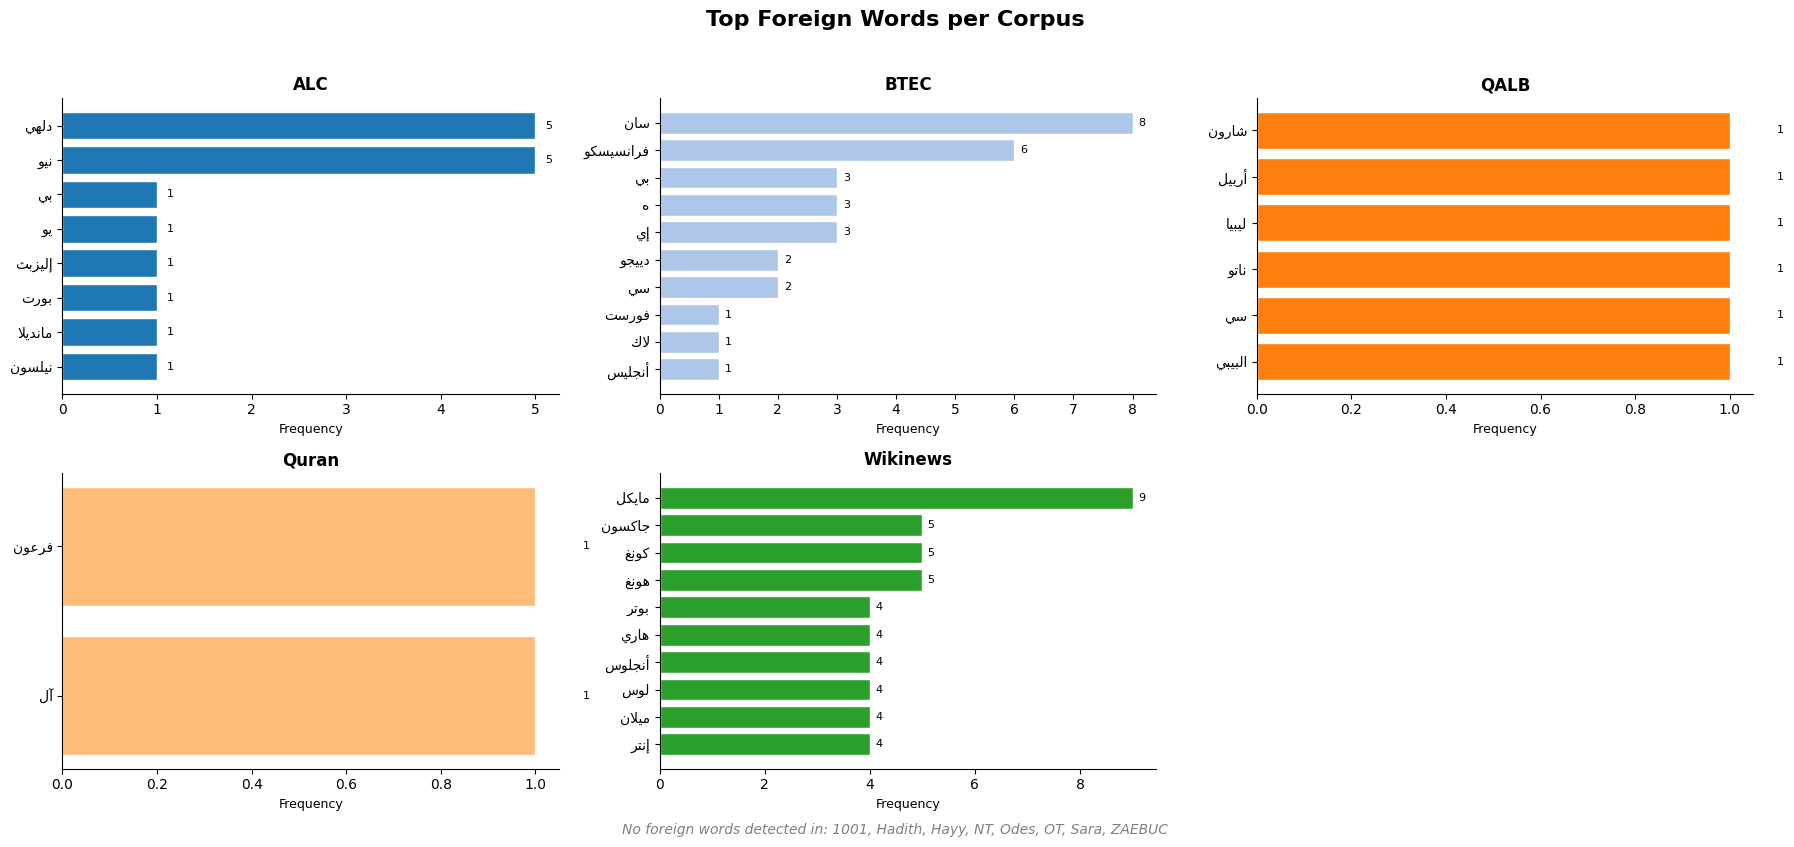

Saved to analysis_images/foreign_words.png


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from bidi.algorithm import get_display
import arabic_reshaper

def fix_arabic(text):
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

def plot_foreign_words(foreign_corpus, top_n=10, filename="analysis_images/foreign_words.png"):
    non_empty = {name: counter for name, counter in foreign_corpus.items() if counter}
    
    n_docs = len(non_empty)
    n_cols = 3
    n_rows = -(-n_docs // n_cols) 

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()
    colors = plt.cm.tab20.colors

    for i, (name, counter) in enumerate(non_empty.items()):
        ax = axes[i]
        top = counter.most_common(top_n)
        words, counts = zip(*top)

        fixed_words = [fix_arabic(w) for w in words]
        y_pos = np.arange(len(fixed_words))

        ax.barh(y_pos, counts, color=colors[i % len(colors)], edgecolor="white")
        ax.set_yticks(y_pos)
        ax.set_yticklabels(fixed_words, fontsize=10)
        ax.invert_yaxis()
        ax.set_title(fix_arabic(name), fontweight="bold", fontsize=12)
        ax.set_xlabel("Frequency", fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)

        for j, count in enumerate(counts):
            ax.text(count + 0.1, j, str(count), va='center', fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    empty = [name for name, counter in foreign_corpus.items() if not counter]
    if empty:
        fig.text(0.5, -0.01, f"No foreign words detected in: {', '.join(empty)}",
                 ha='center', fontsize=10, color='gray', style='italic')

    plt.suptitle("Top Foreign Words per Corpus", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(filename, dpi=500, bbox_inches="tight")
    plt.show()
    print(f"Saved to {filename}")

plot_foreign_words(foreign_corpus, top_n=10)